## Comparison of two implementations for calculating PHDim 

In this notebook, we will see a comparison of two different PhD scoring implementations. They differ in that the matrix of pairwise distances is considered in the method of calculating
the matrix of pairwise distances. It can be read on the CPU, or it can be read on cuda.  It turns out that when the embedding dimension is > 5000, the difference is already
significant, especially for long texts > 500 tokens.

In [4]:
%load_ext autoreload
%autoreload 2


    

In [5]:
import skdim
import torch
import pickle 
from phdim import PH, pairwise_distances
from scipy.spatial.distance import cdist


def data(n=100, d=5):
    X = skdim.datasets.hyperBall(n=n, d=d, radius=1, random_state=0)
    return X

## Start Benchmarking

In [43]:
import numpy as np
import time


def cuda_benchmark(X, n_tries=1, use_cuda_device_synchronize=True, cuda_device='cuda:2'):
    times = []
    dims = []
    for _ in range(n_tries):
        start_time = time.time()
        X_dist = pairwise_distances(torch.Tensor(X).to(cuda_device)).cpu().numpy()
        ph = PH(
            cuda_device=cuda_device,
            distance_matrix=True,
            alpha=1.0,
            restarts=3,
            resamples=3
        )

        dim = ph.fit_transform(X_dist)
        if use_cuda_device_synchronize:
            torch.cuda.synchronize()
        delta = time.time() - start_time
        times.append(delta)
        dims.append(dim)

#    print("cuda:  median - ",  np.median(times), " +- ",  np.std(times))

    return np.median(times), np.std(times), np.median(dims), np.std(dims)


def cpu_benchmark(X, n_tries=1):
    times = []
    dims = []
    for _ in range(n_tries):
        start_time = time.time()
        ph = PH(
            cuda_device=None,
            distance_matrix=True,
            alpha=1.0,
            restarts=3,
            resamples=3
        )
        X_dist = cdist(X, X)
        
        dim = ph.fit_transform(X_dist)
        delta = time.time() - start_time
        times.append(delta)
        dims.append(dim)

#    print("cpu:  median - ",  np.median(times), " +- ",  np.std(times))

    
    return np.median(times), np.std(times), np.median(dims), np.std(dims)


def test_correctness(X):
    cuda_time_median, cuda_time_std, cuda_dim_med, cuda_dim_std = cuda_benchmark(X, n_tries=1000)
    cpu_time_median, cpu_time_std, cpu_dim_med, cpu_dim_std = cpu_benchmark(X, n_tries=1000)

    assert np.abs(cuda_dim_med - cpu_dim_med) < 0.1, "median doesn't close"
    assert np.abs(cuda_dim_std - cpu_dim_std) < 0.1, "std's doesn't close"

In [13]:
test_correctness(data(100, 5))

cuda:  median -  0.03811204433441162  +-  0.002670621299002021
cpu:  median -  0.03354156017303467  +-  0.000103922781395824


In [44]:
import torch.utils.benchmark as benchmark


def start_benchmark(n=100, d=5):
    X = data(n=n, d=d)
    t0 = benchmark.Timer(
        stmt='cpu_benchmark(X)',
        setup='from __main__ import cpu_benchmark',
        globals={'X': X, 'd': d})
    
    t1 = benchmark.Timer(
        stmt='cuda_benchmark(X)',
        setup='from __main__ import cuda_benchmark',
        globals={'X': X, 'd': d})
    
    result_t0 = t0.timeit(2)
    result_t1 = t1.timeit(2)

#    print("cpu: ", result_t0.median, "+-", result_t0.iqr)
#    print("cuda: ", result_t1.median, "+-", result_t1.iqr)

    return result_t0.median, result_t1.median, result_t0.iqr, result_t1.iqr

## Use torch benchmark 

In [62]:
from tqdm import tqdm


d_list = [5, 5000, 50000]
n_list = [i * 100 for i in range(1, 6)]
params2time = dict()

for n in tqdm(n_list):
    for d in d_list:
#        print(f"n = {n}, d = {d} is start computing...")
        params2time[(n, d)] = start_benchmark(n=n, d=d)
#        print("next iteration")
with open("new_times.pickle", "wb") as fd:
    pickle.dump(params2time, fd)

100%|██████████| 5/5 [01:11<00:00, 14.39s/it]


## Use torch.cuda.synchronize()

In [ ]:
params2time = dict()

for n in tqdm(n_list):
    for d in d_list:
        # print(f"n = {n}, d = {d} is start computing...")
        X = data(n, d)
        # print(X.shape)
        params2time[(n, d)] = cpu_benchmark(X, 5), cuda_benchmark(X, 5)
        # print("next iteration")
with open("new_times_without_torch_bench.pickle", "wb") as fd:
    pickle.dump(params2time, fd)

 80%|████████  | 4/5 [00:50<00:15, 15.85s/it]

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")


def plot_times(filename, use_unveiling=True):
    with open(filename, "rb") as fd:
        params2time = pickle.load(fd)
    
    df_times = pd.DataFrame(params2time).T.rename(columns={0: 'cpu', 1: 'cuda'})
    if use_unveiling:
        df_times['cpu_median'] = df_times['cpu'].apply(lambda x: x[0])
        df_times['cpu_std'] = df_times['cpu'].apply(lambda x: x[1])
        
        df_times['cuda_median'] = df_times['cuda'].apply(lambda x: x[0])
        df_times['cuda_std'] = df_times['cuda'].apply(lambda x: x[1])
    else:
        df_times = df_times.rename(columns={'cpu': 'cpu_median', 'cuda': 'cuda_median'})
        
    df_times = df_times.reset_index()
    df_times = df_times.rename(columns={'level_0': 'n', 'level_1': 'd'})
    if use_unveiling:
        df_times = df_times.drop(['cpu', 'cuda'], axis=1)

    for d in d_list:
        df_filter = df_times.query("d == @d")
        plt.plot(df_filter['n'].values.tolist(), df_filter['cpu_median'], label='cpu')
        plt.plot(df_filter['n'].values.tolist(), df_filter['cuda_median'], label='cuda')
        plt.xlabel("number of tokens")
        plt.ylabel("seconds")
        plt.title(f"cpu vs cuda times d = {d}") 
        plt.legend()
        plt.show()

    for d in d_list:
        plt.plot(df_filter['n'].values.tolist(), df_times.query("d == @d")['cuda_median'], label=f'd = {d}')

    plt.legend()
    plt.xlabel("number of tokens")
    plt.ylabel("seconds")
    plt.title(f"cuda times,  d $\in {d_list}$") 
    plt.show()
        

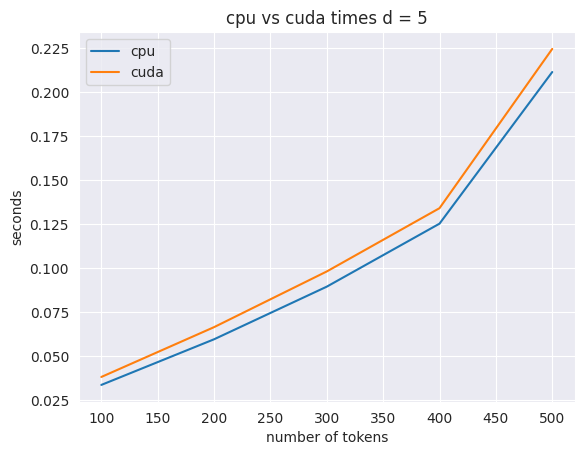

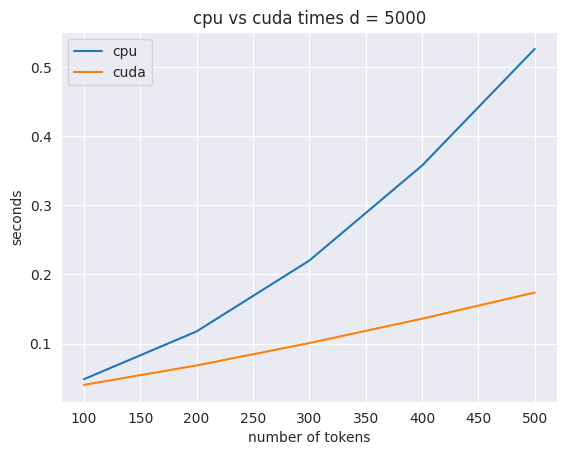

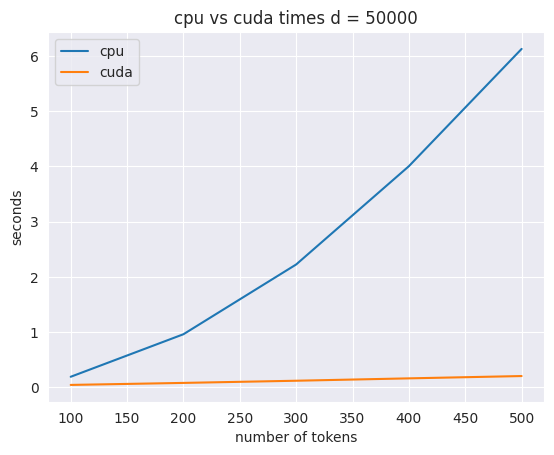

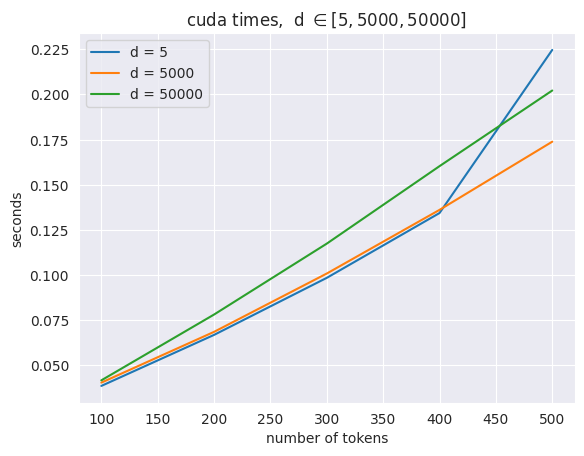

In [68]:
# without torch benchmark
plot_times("new_times_without_torch_bench.pickle")

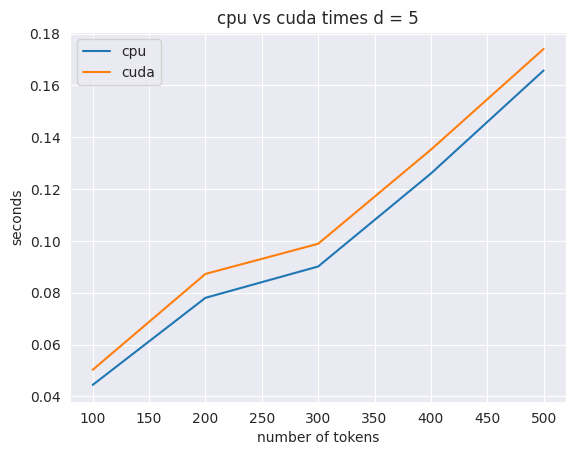

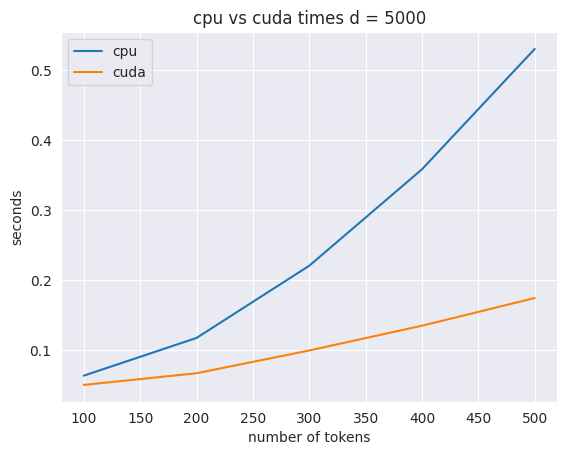

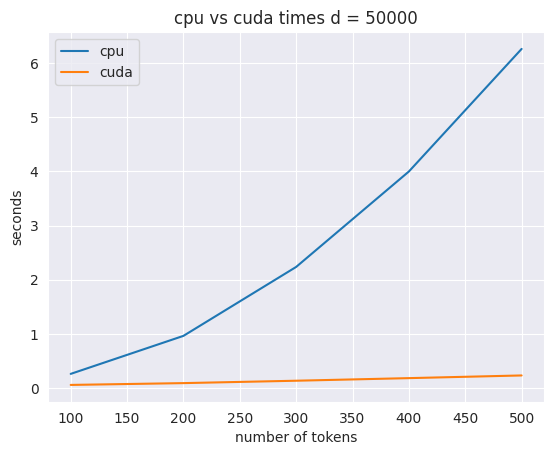

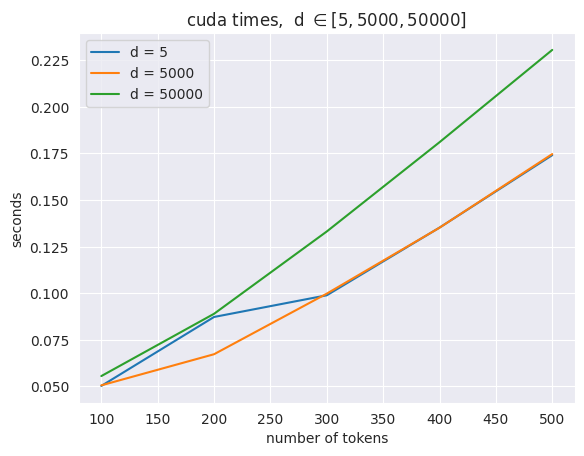

In [69]:
# with torch.benchmark

plot_times("new_times.pickle", False)

# Here we can see that cuda version of calculation PHD is significant better when d >5000. It's useful for calculation ID of hidden state of LLM 